In [91]:
# !pip install dotenv

In [92]:
import pandas as pd
import numpy as np
from pymongo import MongoClient

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv




In [93]:
load_dotenv()

print("USER:", os.getenv("MONGO_USER"))
print("PASS:", os.getenv("MONGO_PASS"))
print("CLUSTER:", os.getenv("MONGO_CLUSTER"))


USER: iveymistele
PASS: Frostyccino1
CLUSTER: cluster0.93xer.mongodb.net


In [94]:
# Prep data
from pymongo import MongoClient
import pandas as pd

# Config
MONGO_PASS = os.getenv('MONGO_PASS')
MONGO_USER = "iveymistele"
MONGO_CLUSTER = "cluster0.93xer.mongodb.net"

MONGO_URI = f"mongodb+srv://{MONGO_USER}:{MONGO_PASS}@{MONGO_CLUSTER}/?retryWrites=true&w=majority"


In [95]:
client = MongoClient(MONGO_URI)
db = client["epstein_db"]
collection = db["emails"]

data = list(collection.find({}))
df = pd.DataFrame(data)

# basic cleaning
#df = df.dropna(subset=["from", "to", "body"])

In [96]:
print(df.columns.tolist())

['_id', 'document_id', 'email_text', 'source_file', 'is_email', 'participants', 'date', 'time', 'subject', 'has_attachments', 'attachment_names', 'people_mentioned', 'organizations', 'locations', 'phone_numbers', 'urls', 'notable_figures', 'primary_topic', 'topics', 'inferred_people', 'summary', 'key_quotes', 'tone', 'potential_crimes', 'evidence_strength', 'crime_types', 'mentions_victims', 'victim_names', 'cover_up', 'timestamp', 'participant_names', 'participant_emails', 'participant_count', 'attachment_count', 'url_count']


In [97]:
import pandas as pd

df = df.copy()

# keep columns most useful for analysis
df = df[
    [
        "_id",
        "document_id",
        "email_text",
        "subject",
        "date",
        "participant_names",
        "participant_emails",
        "participant_count",
        "people_mentioned",
        "organizations",
        "locations",
        "topics",
        "primary_topic",
        "tone",
        "evidence_strength",
        "crime_types",
        "mentions_victims",
        "victim_names",
        "attachment_count",
        "url_count"
    ]
].copy()

# clean text
df["email_text"] = df["email_text"].fillna("").astype(str).str.strip()
df["subject"] = df["subject"].fillna("").astype(str).str.strip()
df["primary_topic"] = df["primary_topic"].fillna("Unknown").astype(str).str.strip()
df["tone"] = df["tone"].fillna("Unknown").astype(str).str.strip()

# remove empty emails
df = df[df["email_text"] != ""].copy()

print(df.shape)
df.head()

(2322, 20)


,_id,document_id,email_text,subject,date,participant_names,participant_emails,participant_count,people_mentioned,organizations,locations,topics,primary_topic,tone,evidence_strength,crime_types,mentions_victims,victim_names,attachment_count,url_count
0,HOUSE_OVERSIGHT_011277,HOUSE_OVERSIGHT_011277,"From: Ens, Amand \nSent: 12/9/2016 3:46:19 PM ...",RE: Financials: buy XLF call spreads,2016-12-09,"[Amand Ens, Jeffrey Epstein, Rich Kahn]","[amand.ens@bofa.com, jeeyacation@gmail.com]",3,"[Amanda Ens, Rich Kahn, Erika Najarian, Nigel ...","[Bank of America Merrill Lynch, Merrill Lynch ...","[New York, NY, One Bryant Park]","[financial, business]",financial,routine,none,[],False,[],1,1
1,HOUSE_OVERSIGHT_012037,HOUSE_OVERSIGHT_012037,From: jeffrey E. [jeeyacation@gmail.com] \nSen...,Re: Press: AmLaw Litigation Daily on Emirates ...,2016-08-15,"[Jeffrey Epstein, Kathy Ruemmler, Schecter Dan...",[jeeyacation@gmail.com],21,"[Jeffrey Epstein, Kathy Ruemmler, Daniel Schec...","[Emirates NBD Bank PJSC, Latham & Watkins LLP,...","[Orange County, California, Dubai, UAE, United...","[legal, media_pr, business]",legal,routine,none,[],False,[],0,8
2,HOUSE_OVERSIGHT_011280,HOUSE_OVERSIGHT_011280,"From: Ens, Amanda_____________________________...",RE: Financials: buy XLF call spreads,2016-12-09,"[Amanda Ens, Jeffrey Epstein, Richard Kah, Ric...",[jeeyacation@gmail.com],4,"[Amanda Ens, Jeffrey Epstein, Richard Kahn, Er...","[Bank of America Merrill Lynch, Merrill Lynch,...","[New York, NY, North America, United States]","[financial, business]",financial,routine,none,[],False,[],1,1
3,HOUSE_OVERSIGHT_012722,HOUSE_OVERSIGHT_012722,﻿From: ASMALLWORLD@travel.asmallworld.net\nTo:...,"ASW Travel Deals: Sky Dive Mount Everest, See ...",2011-08-03,[],"[ASMALLWORLD@travel.asmallworld.net, jeeprojec...",2,"[James Madison, Dalai Lama]","[ASMALLWORLD, Jetsetter, Everest Skydive, Moru...","[Mount Everest, New York, Dream Downtown, Chel...",[travel],travel,routine,none,[],False,[],0,50
4,HOUSE_OVERSIGHT_011904,HOUSE_OVERSIGHT_011904,From: Lawrence Krauss \nSent: 4/5/2018 10:16:5...,Re:,2018-04-05,"[Lawrence Krauss, Jeffrey Epstein, Tina Brown]",[jeeyacation@gmail.com],3,"[Lawrence Krauss, Kevin Spacey, Bill Clinton, ...","[The Origins Project at ASU, Arizona State Uni...","[Tempe, AZ]",[social],social,informal,none,[],False,[],1,3


In [98]:
"""# numeric features
df["email_length"] = df["email_text"].str.len()
df["word_count"] = df["email_text"].str.split().str.len()

df["participant_count"] = pd.to_numeric(df["participant_count"], errors="coerce").fillna(0)
df["attachment_count"] = pd.to_numeric(df["attachment_count"], errors="coerce").fillna(0)
df["url_count"] = pd.to_numeric(df["url_count"], errors="coerce").fillna(0)

df[["email_length", "word_count", "participant_count", "attachment_count", "url_count"]].describe()"""

'# numeric features\ndf["email_length"] = df["email_text"].str.len()\ndf["word_count"] = df["email_text"].str.split().str.len()\n\ndf["participant_count"] = pd.to_numeric(df["participant_count"], errors="coerce").fillna(0)\ndf["attachment_count"] = pd.to_numeric(df["attachment_count"], errors="coerce").fillna(0)\ndf["url_count"] = pd.to_numeric(df["url_count"], errors="coerce").fillna(0)\n\ndf[["email_length", "word_count", "participant_count", "attachment_count", "url_count"]].describe()'

In [99]:
"""from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    min_df=2
)

X_text = vectorizer.fit_transform(df["email_text"])

print(X_text.shape)"""

'from sklearn.feature_extraction.text import TfidfVectorizer\n\nvectorizer = TfidfVectorizer(\n    stop_words="english",\n    max_features=500,\n    min_df=2\n)\n\nX_text = vectorizer.fit_transform(df["email_text"])\n\nprint(X_text.shape)'

In [100]:
"""from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_text)

df["cluster"].value_counts().sort_index()"""

'from sklearn.cluster import KMeans\n\nkmeans = KMeans(n_clusters=3, random_state=42, n_init=10)\ndf["cluster"] = kmeans.fit_predict(X_text)\n\ndf["cluster"].value_counts().sort_index()'

In [101]:
"""cluster_summary = df.groupby("cluster").agg(
    email_count=("email_text", "count"),
    avg_email_length=("email_length", "mean"),
    avg_word_count=("word_count", "mean"),
    avg_participant_count=("participant_count", "mean"),
    avg_attachment_count=("attachment_count", "mean"),
    avg_url_count=("url_count", "mean")
)

cluster_summary"""

'cluster_summary = df.groupby("cluster").agg(\n    email_count=("email_text", "count"),\n    avg_email_length=("email_length", "mean"),\n    avg_word_count=("word_count", "mean"),\n    avg_participant_count=("participant_count", "mean"),\n    avg_attachment_count=("attachment_count", "mean"),\n    avg_url_count=("url_count", "mean")\n)\n\ncluster_summary'

In [102]:
"""terms = vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for i in range(kmeans.n_clusters):
    top_indices = centers[i].argsort()[::-1][:10]
    top_terms = [terms[j] for j in top_indices]
    print(f"Cluster {i}: {', '.join(top_terms)}")"""

'terms = vectorizer.get_feature_names_out()\ncenters = kmeans.cluster_centers_\n\nfor i in range(kmeans.n_clusters):\n    top_indices = centers[i].argsort()[::-1][:10]\n    top_terms = [terms[j] for j in top_indices]\n    print(f"Cluster {i}: {\', \'.join(top_terms)}")'

In [103]:
"""from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X_text.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.7)
plt.title("KMeans Clusters of Epstein Emails (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()"""

'from sklearn.decomposition import PCA\nimport matplotlib.pyplot as plt\n\nX_dense = X_text.toarray()\n\npca = PCA(n_components=2, random_state=42)\nX_pca = pca.fit_transform(X_dense)\n\nplt.figure(figsize=(10, 6))\nplt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.7)\nplt.title("KMeans Clusters of Epstein Emails (PCA Projection)")\nplt.xlabel("Principal Component 1")\nplt.ylabel("Principal Component 2")\nplt.show()'

In [104]:
"""cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Emails in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()"""

'cluster_counts = df["cluster"].value_counts().sort_index()\n\nplt.figure(figsize=(8, 5))\nplt.bar(cluster_counts.index.astype(str), cluster_counts.values)\nplt.title("Number of Emails in Each Cluster")\nplt.xlabel("Cluster")\nplt.ylabel("Count")\nplt.show()'

In [105]:
"""for c in sorted(df["cluster"].unique()):
    print(f"\n--- Cluster {c} sample emails ---")
    sample_rows = df[df["cluster"] == c][["subject", "primary_topic", "tone", "email_text"]].head(3)
    
    for _, row in sample_rows.iterrows():
        print("\nSubject:", row["subject"])
        print("Primary topic:", row["primary_topic"])
        print("Tone:", row["tone"])
        print("Email preview:", row["email_text"][:500])
        print("-" * 60)"""

'for c in sorted(df["cluster"].unique()):\n    print(f"\n--- Cluster {c} sample emails ---")\n    sample_rows = df[df["cluster"] == c][["subject", "primary_topic", "tone", "email_text"]].head(3)\n\n    for _, row in sample_rows.iterrows():\n        print("\nSubject:", row["subject"])\n        print("Primary topic:", row["primary_topic"])\n        print("Tone:", row["tone"])\n        print("Email preview:", row["email_text"][:500])\n        print("-" * 60)'

In [106]:
'""pd.crosstab(df["cluster"], df["primary_topic"])""'

'""pd.crosstab(df["cluster"], df["primary_topic"])""'

In [107]:
"""pd.crosstab(df["cluster"], df["tone"])"""

'pd.crosstab(df["cluster"], df["tone"])'

In [108]:
"""pd.crosstab(df["cluster"], df["evidence_strength"])"""

'pd.crosstab(df["cluster"], df["evidence_strength"])'

# Network Analysis

In [109]:
# !pip install networkx

In [110]:
import networkx as nx
import itertools

G = nx.Graph()



for people in df["people_mentioned"]:
    if isinstance(people, list) and len(people) > 1:
        people = list(set(people))  # remove duplicates
        
        for a, b in itertools.combinations(people, 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                G.add_edge(a, b, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 4503
Edges: 103522


In [111]:
# add node sizes
from collections import Counter

counts = Counter()

def clean_people(people):
    if isinstance(people, list):
        return [p for p in people if len(p.split()) > 1]
    return []

df["people_clean"] = df["people_mentioned"].apply(clean_people)

for people in df["people_clean"]:
    if isinstance(people, list):
        counts.update(people)

for node in G.nodes():
    G.nodes[node]["count"] = counts[node]

In [112]:
"""# keep top 15 most mentioned people
top_people = set([p for p, _ in counts.most_common(15)])

G_sub = G.subgraph(top_people).copy()

print("Filtered nodes:", G_sub.number_of_nodes())
"""

'# keep top 15 most mentioned people\ntop_people = set([p for p, _ in counts.most_common(15)])\n\nG_sub = G.subgraph(top_people).copy()\n\nprint("Filtered nodes:", G_sub.number_of_nodes())\n'

In [113]:
"""import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_sub, seed=42)

node_sizes = [G_sub.nodes[n]["count"] * 5 for n in G_sub.nodes()]
edge_widths = [G_sub[u][v]["weight"] * 0.2 for u, v in G_sub.edges()]

centrality = nx.degree_centrality(G_sub)

node_colors = [centrality[n] for n in G_sub.nodes()]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colors,
    cmap=plt.cm.viridis,alpha=0.7)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.5)
nx.draw_networkx_labels(G_sub, pos, font_size=8)

plt.title("Co-occurrence Network of Individuals in Epstein Emails")
plt.axis("off")
plt.show()
"""

'import matplotlib.pyplot as plt\n\nplt.figure(figsize=(12, 10))\n\npos = nx.spring_layout(G_sub, seed=42)\n\nnode_sizes = [G_sub.nodes[n]["count"] * 5 for n in G_sub.nodes()]\nedge_widths = [G_sub[u][v]["weight"] * 0.2 for u, v in G_sub.edges()]\n\ncentrality = nx.degree_centrality(G_sub)\n\nnode_colors = [centrality[n] for n in G_sub.nodes()]\n\nnx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colors,\n    cmap=plt.cm.viridis,alpha=0.7)\nnx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.5)\nnx.draw_networkx_labels(G_sub, pos, font_size=8)\n\nplt.title("Co-occurrence Network of Individuals in Epstein Emails")\nplt.axis("off")\nplt.show()\n'

In [114]:
# 1. build co occurence graph
import itertools
import networkx as nx
from collections import Counter

def build_cooccurrence_graph(docs, min_edge_weight=1):
    """
    docs: iterable of lists of names, one list per document
    """
    edge_counter = Counter()
    node_counter = Counter()

    for names in docs:
        # remove duplicates within a document
        unique_names = sorted(set(names))
        for name in unique_names:
            node_counter[name] += 1
        for u, v in itertools.combinations(unique_names, 2):
            edge_counter[(u, v)] += 1

    G = nx.Graph()

    for node, count in node_counter.items():
        G.add_node(node, count=count)

    for (u, v), weight in edge_counter.items():
        if weight >= min_edge_weight:
            G.add_edge(u, v, weight=weight)

    return G

In [115]:
# compute influence metrics
import pandas as pd

def compute_influence_metrics(G):
    weighted_degree = dict(G.degree(weight="weight"))
    degree_centrality = nx.degree_centrality(G)

    # Optional upgrade
    pagerank = nx.pagerank(G, weight="weight") if len(G) > 0 else {}

    df = pd.DataFrame({
        "name": list(G.nodes()),
        "document_frequency": [G.nodes[n].get("count", 0) for n in G.nodes()],
        "weighted_degree": [weighted_degree.get(n, 0) for n in G.nodes()],
        "degree_centrality": [degree_centrality.get(n, 0) for n in G.nodes()],
        "pagerank": [pagerank.get(n, 0) for n in G.nodes()],
    })

    return df.sort_values("weighted_degree", ascending=False).reset_index(drop=True)

In [116]:
# bootstrap
import numpy as np

def bootstrap_centrality(docs, n_boot=200, metric="weighted_degree", random_state=42):
    """
    docs: list of lists of names
    """
    rng = np.random.default_rng(random_state)
    n_docs = len(docs)
    results = []

    for b in range(n_boot):
        sample_idx = rng.choice(n_docs, size=n_docs, replace=True)
        sampled_docs = [docs[i] for i in sample_idx]

        G_boot = build_cooccurrence_graph(sampled_docs)
        metrics_df = compute_influence_metrics(G_boot)[["name", metric]].copy()
        metrics_df["bootstrap_iter"] = b
        results.append(metrics_df)

    boot_df = pd.concat(results, ignore_index=True)
    return boot_df

In [117]:
# summarize stability 
def summarize_bootstrap_results(boot_df, metric="weighted_degree"):
    summary = (
        boot_df.groupby("name")[metric]
        .agg(
            mean="mean",
            std="std",
            q025=lambda x: x.quantile(0.025),
            q975=lambda x: x.quantile(0.975),
            median="median"
        )
        .reset_index()
        .sort_values("mean", ascending=False)
        .reset_index(drop=True)
    )
    return summary

In [118]:
docs = df["people_clean"].tolist()

G = build_cooccurrence_graph(docs)
influence_df = compute_influence_metrics(G)

boot_df = bootstrap_centrality(docs, n_boot=300, metric="weighted_degree")
boot_summary = summarize_bootstrap_results(boot_df, metric="weighted_degree")

print(influence_df.head(10))
print(boot_summary.head(10))

                name  document_frequency  weighted_degree  degree_centrality  \
0    Jeffrey Epstein                1810             9646           0.678689   
1       Donald Trump                 559             2784           0.260097   
2       Bill Clinton                 260             2778           0.209296   
3      Prince Andrew                 107             1391           0.087376   
4  Ghislaine Maxwell                  96             1113           0.067310   
5       Barack Obama                  89             1095           0.158242   
6      Larry Summers                 111             1066           0.102616   
7        Woody Allen                  47             1038           0.130302   
8         Bill Gates                  51             1022           0.078994   
9      Darren Indyke                 123              904           0.076454   

   pagerank  
0  0.040321  
1  0.011297  
2  0.008650  
3  0.004054  
4  0.003216  
5  0.004747  
6  0.003688  
7  0.00

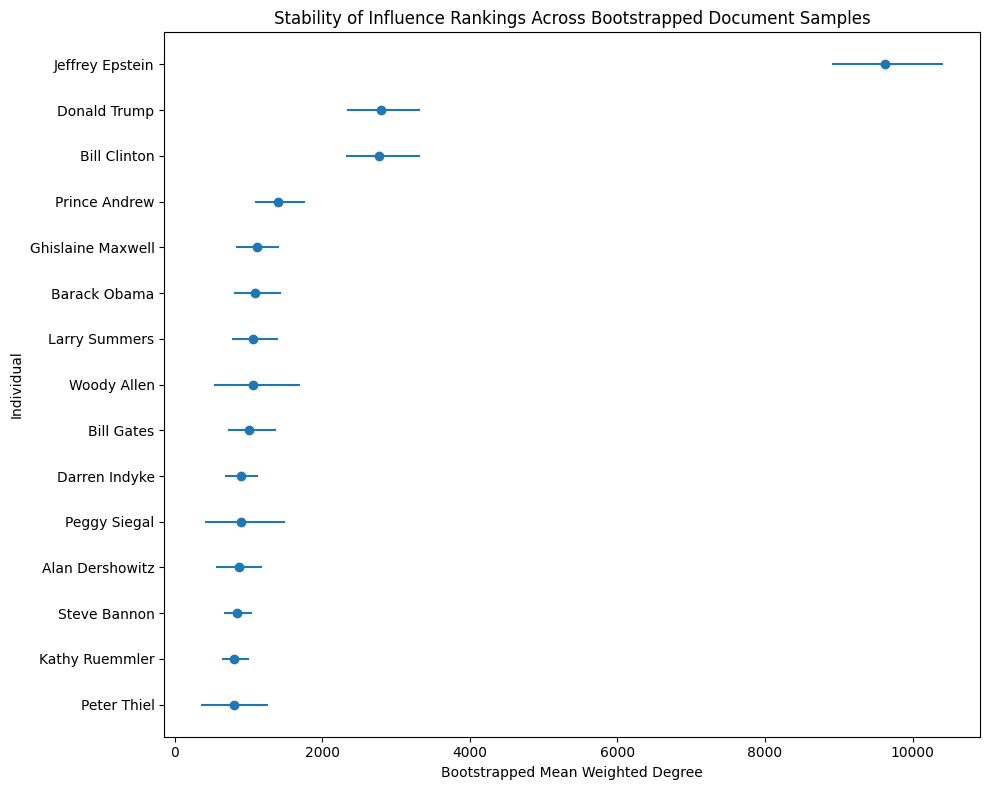

In [119]:
# plot
import matplotlib.pyplot as plt

top_n = 15
plot_df = boot_summary.head(top_n).sort_values("mean")

plt.figure(figsize=(10, 8))
plt.errorbar(
    x=plot_df["mean"],
    y=plot_df["name"],
    xerr=[plot_df["mean"] - plot_df["q025"], plot_df["q975"] - plot_df["mean"]],
    fmt="o"
)

plt.xlabel("Bootstrapped Mean Weighted Degree")
plt.ylabel("Individual")
plt.title("Stability of Influence Rankings Across Bootstrapped Document Samples")
plt.tight_layout()
plt.show()

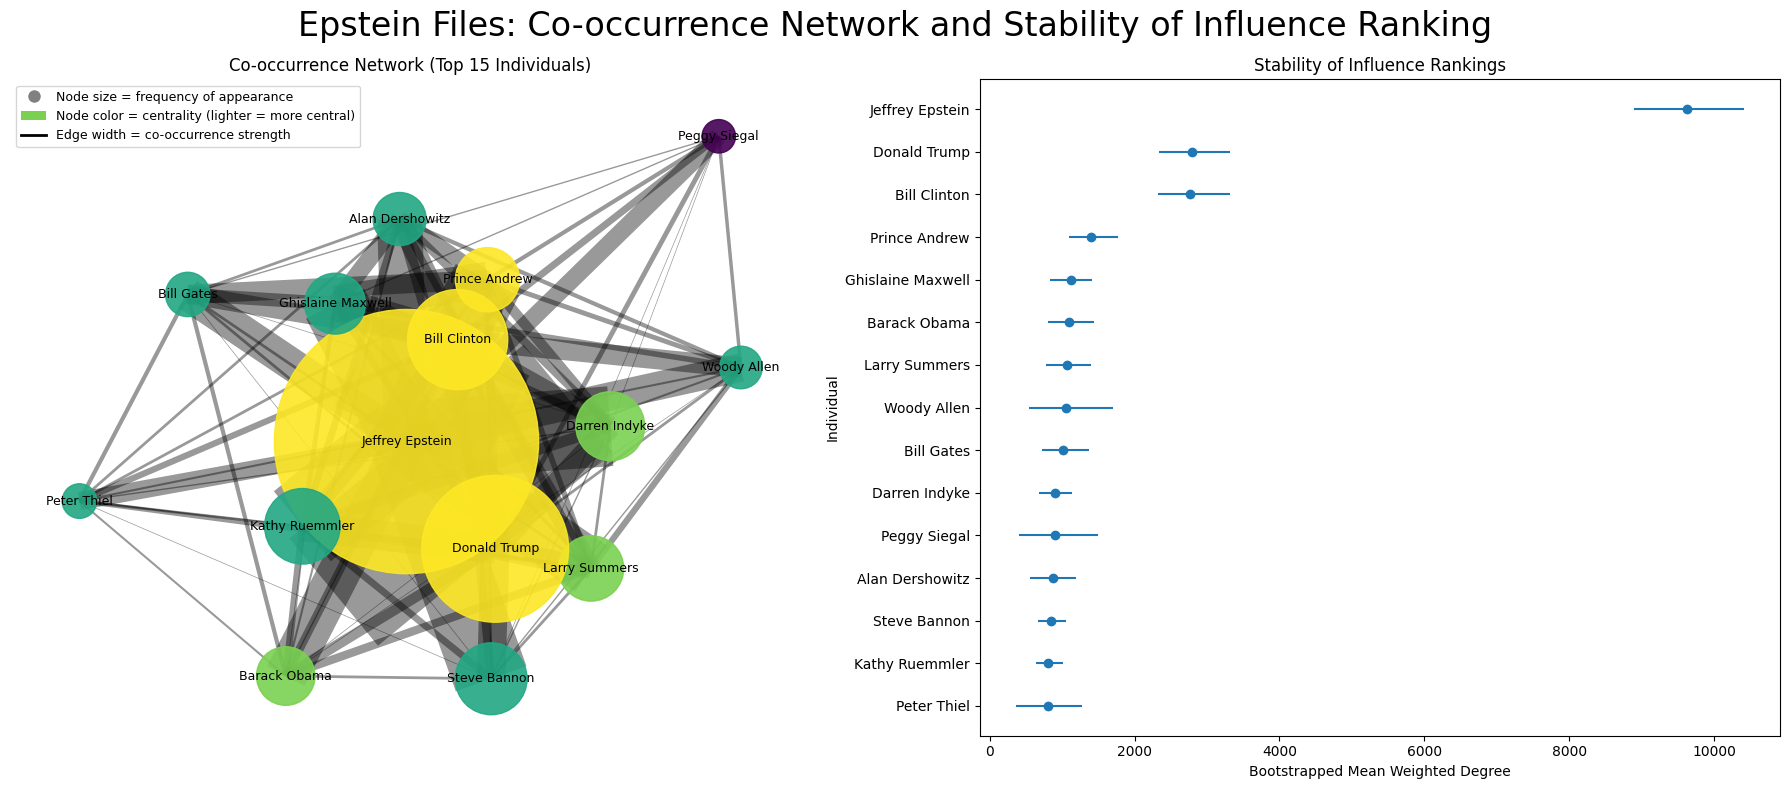

In [120]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------------------------
# LEFT: simpler network graph
# -------------------------
ax = axes[0]

# keep only top names from bootstrap summary
top_nodes = boot_summary.head(15)["name"].tolist()

# make a subgraph using only those names
G_plot = G.subgraph(top_nodes).copy()

pos = nx.spring_layout(G_plot, seed=42, k=1.2)

# manually separate the biggest nodes a bit
if "Jeffrey Epstein" in pos:
    pos["Jeffrey Epstein"] += [-0.08, 0.02]

if "Donald Trump" in pos:
    pos["Donald Trump"] += [0.10, -0.08]

if "Bill Clinton" in pos:
    pos["Bill Clinton"] += [-0.02, 0.12]

node_sizes = [G_plot.nodes[n].get("count", 1) * 20 for n in G_plot.nodes()]
edge_widths = [G_plot[u][v].get("weight", 1) * 0.5 for u, v in G_plot.edges()]

centrality = nx.degree_centrality(G_plot)
node_colors = [centrality[n] for n in G_plot.nodes()]

nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=ax
)

nx.draw_networkx_edges(
    G_plot,
    pos,
    width=edge_widths,
    alpha=0.4,
    ax=ax
)

nx.draw_networkx_labels(
    G_plot,
    pos,
    font_size=9,
    ax=ax
)

# Create custom legend elements
legend_elements = [

    # Node size meaning
    Line2D([0], [0], marker='o', color='w',
           label='Node size = frequency of appearance',
           markerfacecolor='gray', markersize=10),

    # Node color meaning
    Patch(facecolor=plt.cm.viridis(0.8),
          label='Node color = centrality (lighter = more central)'),

    # Edge width meaning
    Line2D([0], [0], color='black', lw=2,
           label='Edge width = co-occurrence strength'),

]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=True,
    fontsize=9
)

ax.set_title("Co-occurrence Network (Top 15 Individuals)")
ax.axis("off")

# -------------------------
# RIGHT: bootstrap stability
# -------------------------
ax = axes[1]

plot_df = boot_summary.head(15).sort_values("mean")

ax.errorbar(
    x=plot_df["mean"],
    y=plot_df["name"],
    xerr=[
        plot_df["mean"] - plot_df["q025"],
        plot_df["q975"] - plot_df["mean"]
    ],
    fmt="o"
)

ax.set_xlabel("Bootstrapped Mean Weighted Degree")
ax.set_ylabel("Individual")
ax.set_title("Stability of Influence Rankings")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig.suptitle("Epstein Files: Co-occurrence Network and Stability of Influence Ranking", fontsize=24)

plt.tight_layout()
plt.show()